In [1]:
%matplotlib widget
import hyperspy.api as hs
import h5py as h5
import matplotlib.pyplot as plt
import numpy as np
import json
import imageio, os, glob
import pandas as pd
import seaborn as sns

In [2]:
root_path = '/dls/e02/data/2026/mg44468-1/processing/Merlin/Pt_NP_Overnight_5March2026'
gif_paths = sorted(glob.glob(root_path + '/*/parallax/*.gif'))
json_paths = sorted(glob.glob(root_path + '/*/parallax/*.json'))

In [3]:
json_paths[0].split('/')[-3]

'20260305_164923'

# Looking at the defocus values

In [4]:
data_dict = {}
for _f in json_paths:
    _ts = _f.split('/')[-3]
    with open(_f, 'r') as f:
        _d = json.load(f)
    data_dict[_ts] = _d

In [5]:
df = pd.DataFrame(data_dict)

In [6]:
df = df.T

In [7]:
df = df.reset_index().rename(columns={"index": "timestamp"})

In [8]:
df

,timestamp,C10,C12a,C12b,C21a,C21b,C23a,C23b,C30,C32a,...,C43b,C45a,C45b,C50,C52a,C52b,C54a,C54b,C56a,C56b
0,20260305_164923,-132.284068,-32.005937,6.457329,72.874784,19.697656,0.543117,-0.499211,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20260305_165154,-127.363535,-30.682210,9.814037,59.230444,12.069305,0.495757,-0.361187,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20260305_165821,-101.797916,-10.412375,-0.868204,14.703501,-39.400068,0.227270,-0.014150,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20260305_170052,-96.012625,-20.282571,-0.141038,12.698643,-21.229568,0.159752,-0.018001,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,20260305_170720,-86.652487,-16.762172,4.462883,0.271491,-10.585298,0.008538,0.011174,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,20260306_015322,-496.657107,-31.718607,16.918323,-1167.191023,263.683955,1.914241,-4.060230,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113,20260306_015553,-517.452752,-9.527094,-0.842155,-1196.203060,51.971526,4.888381,3.689130,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114,20260306_020220,-517.754188,-27.822714,10.693554,-1218.733518,241.394496,2.404580,-3.638136,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
115,20260306_020451,-520.231624,-28.824698,8.198873,-1227.252759,205.833639,3.913112,-2.979619,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
plt.close('all')

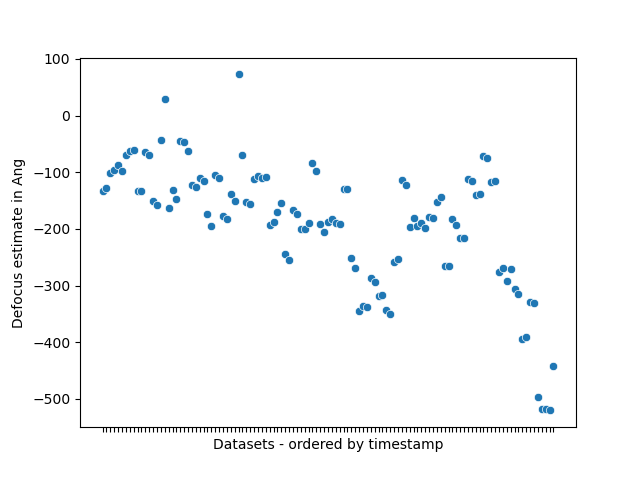

In [10]:
# cols = ["C10", "C12a", "C12b"]

ax = sns.scatterplot(data=df.set_index("timestamp")["C10"])

# handles, labels = ax.get_legend_handles_labels()
# # Filter only selected columns
# filtered = [(h, l) for h, l in zip(handles, labels) if l in cols]
# handles, labels = zip(*filtered)

# Apply the filtered legend outside the plot
# ax.legend(handles, labels,
#     bbox_to_anchor=(1.05, 1),
#     loc="upper left",
#     borderaxespad=0.0
# )


ax.set_ylabel('Defocus estimate in Ang')
ax.set_xlabel('Datasets - ordered by timestamp')
ax.tick_params(axis="x", labelbottom=False)
plt.show()

# Display the gifs from different times of the run to compare

In [63]:
len(gif_paths)

117

In [64]:
indxs = [0, 30, 60, 90]
selected_gifs = [gif_paths[i] for i in indxs]

In [67]:
selected_gifs

['/dls/e02/data/2026/mg44468-1/processing/Merlin/Pt_NP_Overnight_5March2026/20260305_164923/parallax/20260305_164923_def_sweep_stack.gif',
 '/dls/e02/data/2026/mg44468-1/processing/Merlin/Pt_NP_Overnight_5March2026/20260305_192551/parallax/20260305_192551_def_sweep_stack.gif',
 '/dls/e02/data/2026/mg44468-1/processing/Merlin/Pt_NP_Overnight_5March2026/20260305_214818/parallax/20260305_214818_def_sweep_stack.gif',
 '/dls/e02/data/2026/mg44468-1/processing/Merlin/Pt_NP_Overnight_5March2026/20260306_001337/parallax/20260306_001337_def_sweep_stack.gif']

In [68]:
_ts_list = [_f.split('/')[-3] for _f in selected_gifs]
_ts_list

['20260305_164923', '20260305_192551', '20260305_214818', '20260306_001337']

In [66]:
import imageio
import matplotlib.pyplot as plt
import numpy as np

# List of GIF paths
indxs = [0, 30, 60, 90]
selected_gifs = [gif_paths[i] for i in indxs]

# Load GIFs as lists of frames
gifs = [imageio.mimread(path) for path in selected_gifs]
_ts_list = [_f.split('/')[-3] for _f in selected_gifs]

# Convert frames to numpy arrays
gifs = [[np.array(frame) for frame in gif] for gif in gifs]

# Assume all GIFs have same number of frames
num_frames = len(gifs[0])

# Create output writer
writer = imageio.get_writer("tiled.gif", mode="I", loop=0)

# 2×2 grid for 4 GIFs
fig, axes = plt.subplots(2, 2, figsize=(6, 6))


# # Remove all padding between subplots
# fig.subplots_adjust(wspace=0, hspace=0)

# # Remove figure borders
# plt.margins(0)
plt.tight_layout()


for i in range(num_frames):
    for ax, gif_frames, label in zip(axes.flatten(), gifs, _ts_list):
        ax.clear()
        ax.imshow(gif_frames[i])
        ax.set_title(label, fontsize=10)
        
        ax.axis("off")

    fig.canvas.draw()

    # Convert figure to image array
    frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))

    writer.append_data(frame)
    

writer.close()
plt.close(fig)


/tmp/ipykernel_415326/2305797366.py:45: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)


In [2]:
mask_path = '/dls/science/groups/e02/Frederick/DetecotrMasks/29042024_12bitmask2.h5'
# '/dls_sw/e02/medipix_mask/29042024_12bitmask2.h5'
with h5.File(mask_path, 'r') as f:
    mask = f['data/mask'][()]
mask_binary = mask > 0.5

In [7]:
data = '/dls/e02/data/2026/mg44468-1/processing/Merlin/Pt_NP_Overnight_5March2026/20260305_164923/parallax/20260305_164923_def_sweep_stack.hspy'
d = hs.load(data)

In [8]:
d.plot()

In [3]:
d.axes_manager[0].scale = 25 / 10
d.axes_manager[0].units = 'nm'
d.axes_manager[0].offset = -300 / 10

In [4]:
d

<Signal2D, title: , dimensions: (24|132, 132)>

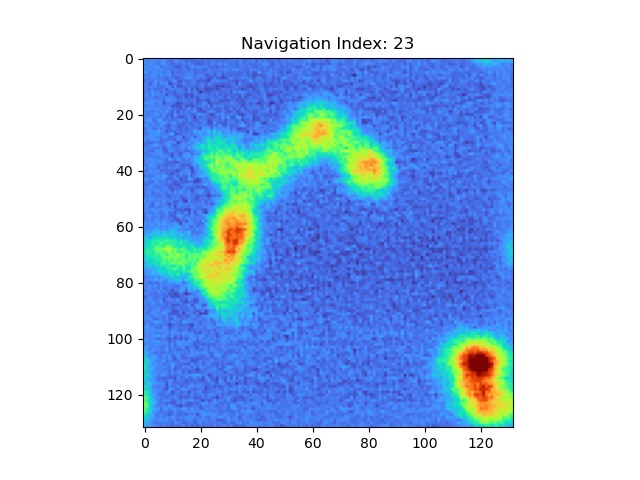

In [12]:
# import hyperspy.api as hs
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation

# # 1. Assume 's' is your signal <Signal2D, dimensions: (24|132, 132)>
# # s = ... 

# # 2. Set up the figure and the initial frame
# fig, ax = plt.subplots()
# # We take the first navigation pixel [0] to initialize the plot
# im = ax.imshow(d.inav[0].data, cmap='turbo')
# ax.set_title("Navigation Index: 0")

# # 3. Define the update function for the animation
# def update(frame):
#     # Update the image data for the current navigation index
#     im.set_data(d.inav[frame].data)
#     ax.set_title(f"Navigation Index: {frame}")
#     return [im]

# # 4. Create the animation
# # frames=24 because your navigation dimension is 24
# ani = FuncAnimation(fig, update, frames=d.axes_manager.navigation_shape[0], 
#                     interval=200, blit=True)

# # 5. Save as GIF
# # Note: You must have 'imagemagick' or 'pillow' installed as a writer
# ani.save('hyperspy_sweep.gif', writer='pillow')

# plt.show()

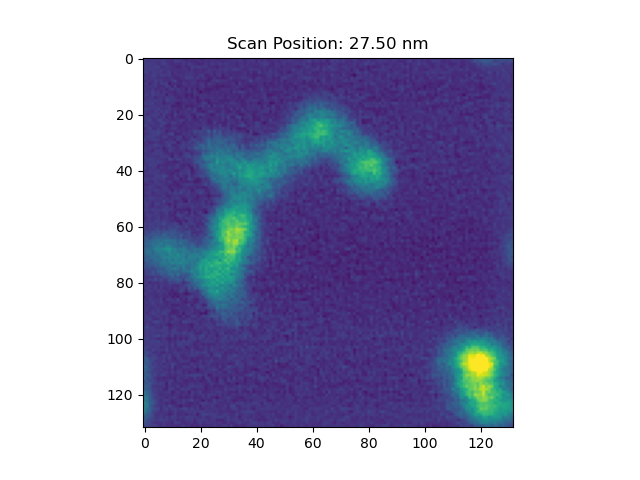

In [5]:
import hyperspy.api as hs
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# 1. Access the navigation axis metadata
nav_axis = d.axes_manager.navigation_axes[0]
units = nav_axis.units
scale = nav_axis.scale
offset = nav_axis.offset

fig, ax = plt.subplots()
im = ax.imshow(d.inav[0].data, cmap='viridis')

# 2. Update function with calibration logic
def update(frame):
    # Calculate the calibrated value for the current frame
    calibrated_value = (frame * scale) + offset
    
    im.set_data(d.inav[frame].data)
    
    # Update title with units (e.g., "Position: 10.5 nm")
    ax.set_title(f"Scan Position: {calibrated_value:.2f} {units}")
    
    return [im]

# 3. Create and save
ani = FuncAnimation(fig, update, frames=d.axes_manager.navigation_shape[0], 
                    interval=200, blit=True)

ani.save('calibrated_sweep.gif', writer='pillow')
plt.show()